In [1]:
import pandas as pd
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:


from custom_datasets.BayesRiskDataset.BayesRiskDatasetLoader import BayesRiskDatasetLoader

# Load the validation dataset
n_hypothesis = 100
n_references = 1000
utility = "comet"

dataset_dir = 'predictive/tatoeba-de-en/data/raw/'
dataset_loader = BayesRiskDatasetLoader('validation_predictive', n_hypothesis, n_references,
                                              "ancestral", utility, develop=False,
                                              base=dataset_dir)
val_df = dataset_loader.load(type="pandas").data




C:\Users\gerso\anaconda3\envs\thesis\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load the predictions

predictions_df = pd.read_parquet('../model_predictions/basic_lstm_model_predictions.parquet')

In [4]:
predictions_df

,source,hypotheses,predictions
0,Ich spreche überhaupt kein Deutsch.,"[I don't speak German at all., I can't speak G...","[0.3447842597961426, 0.4146411418914795, 0.710..."
1,Ich war einmal in deinem Alter.,"[I was once your age., I was your age once., I...","[0.018119363114237785, 0.35631847381591797, -0..."
2,"Ich bat Tom, sich mit mir zu treffen.","[I asked Tom to meet me., I asked Tom to meet ...","[0.8876768350601196, 0.7967453002929688, 0.600..."
3,Sie will wirklich gehen.,"[She really wants to go., She wants to really ...","[0.44063955545425415, 0.5592383146286011, 0.58..."
4,Die Deutschen lieben Bier und Würstchen.,"[Germans love beer andore., Germans love beer ...","[-1.3141106367111206, -1.1886581182479858, -1...."
...,...,...,...
2494,Der AStA betreibt eine Kneipe auf dem Campus.,"[The laboratory A football runs a bar on mad.,...","[-1.131791114807129, -0.8693519234657288, -1.0..."
2495,"Da wo mein Herz ist, bin ich zuhause.","[To the heart, I'm home., That's where my hear...","[-0.06018144637346268, 0.3102697432041168, 0.2..."
2496,Ich mag seinen Pullover.,"[I like his sweater., I love his sweater., I l...","[0.10468493402004242, 0.5305682420730591, -0.8..."
2497,"Weißt du, was mich am meisten ärgert, Tom?","[Do you know what consists of me the most, Tom...","[-0.6076582074165344, 0.1019245982170105, -0.5..."


In [5]:
val_df.drop(1492, inplace=True)
val_df.reset_index(drop=True, inplace=True)
val_df

,source,target,count,hypotheses,utilities_count,utilities
0,Ich spreche überhaupt kein Deutsch.,I can't speak German at all.,"[28, 51, 7, 7, 1, 1, 1, 1, 1, 1, 1]","[I don't speak German at all., I can't speak G...","[56, 396, 385, 14, 88, 8, 1, 2, 7, 6, 1, 2, 1,...","[[0.8252172, 1.1844915, 0.90190655, 1.0234041,..."
1,Ich war einmal in deinem Alter.,I was your age once.,"[32, 10, 1, 45, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1]","[I was once your age., I was your age once., I...","[10, 500, 285, 1, 91, 1, 1, 1, 13, 1, 10, 4, 2...","[[0.6511432, 0.7018407, 1.1397547, 0.5746661, ..."
2,"Ich bat Tom, sich mit mir zu treffen.",I asked Tom to come see me.,"[92, 2, 1, 3, 1, 1]","[I asked Tom to meet me., I asked Tom to meet ...","[944, 1, 1, 15, 7, 1, 1, 12, 1, 4, 1, 1, 1, 2,...","[[1.1275442, 0.8299061, 0.6676044, 0.991237, 0..."
3,Sie will wirklich gehen.,She really wants to go.,"[87, 1, 11, 1]","[She really wants to go., She wants to really ...","[929, 54, 1, 5, 6, 1, 1, 1, 2]","[[1.0670044, 0.6950034, 0.40765765, 0.99740165..."
4,Die Deutschen lieben Bier und Würstchen.,Germans love beer and sausages.,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[Germans love beer andore., Germans love beer ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[[-0.68567187, -0.39454877, -0.7241983, 0.0202..."
...,...,...,...,...,...,...
2494,Der AStA betreibt eine Kneipe auf dem Campus.,The Students' Union runs a bar on campus.,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[The laboratory A football runs a bar on mad.,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[[-0.8414187, -1.1981215, -1.3067422, -1.13866..."
2495,"Da wo mein Herz ist, bin ich zuhause.",Home is where the heart is.,"[1, 2, 2, 2, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, ...","[To the heart, I'm home., That's where my hear...","[16, 4, 1, 15, 1, 1, 4, 3, 1, 43, 8, 2, 1, 23,...","[[0.20953147, -0.8850453, -0.74882835, -0.3123..."
2496,Ich mag seinen Pullover.,I like this sweater.,"[96, 3, 1]","[I like his sweater., I love his sweater., I l...","[956, 38, 2, 1, 1, 1, 1]","[[1.2061013, 1.073937, 1.1033567, 0.34121433, ..."
2497,"Weißt du, was mich am meisten ärgert, Tom?",Do you know what annoys me the most Tom?,"[1, 1, 1, 1, 1, 10, 8, 5, 1, 2, 1, 1, 21, 1, 1...","[Do you know what consists of me the most, Tom...","[1, 225, 73, 1, 69, 1, 10, 1, 1, 1, 1, 16, 1, ...","[[-0.6575369, -0.54586023, -0.9109387, -0.8573..."


In [6]:
from utilities.preprocess.Preprocess import UtilitiesToAverage
preprocess_f = UtilitiesToAverage()
val_df = preprocess_f(val_df)
val_df

,source,target,count,hypotheses,utilities_count,utilities
0,Ich spreche überhaupt kein Deutsch.,I can't speak German at all.,"[28, 51, 7, 7, 1, 1, 1, 1, 1, 1, 1]","[I don't speak German at all., I can't speak G...","[56, 396, 385, 14, 88, 8, 1, 2, 7, 6, 1, 2, 1,...","[0.9981588, 0.9707254, 0.83220214, 0.8852467, ..."
1,Ich war einmal in deinem Alter.,I was your age once.,"[32, 10, 1, 45, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1]","[I was once your age., I was your age once., I...","[10, 500, 285, 1, 91, 1, 1, 1, 13, 1, 10, 4, 2...","[0.8151286, 0.7690606, 0.84139365, 0.8694304, ..."
2,"Ich bat Tom, sich mit mir zu treffen.",I asked Tom to come see me.,"[92, 2, 1, 3, 1, 1]","[I asked Tom to meet me., I asked Tom to meet ...","[944, 1, 1, 15, 7, 1, 1, 12, 1, 4, 1, 1, 1, 2,...","[1.1117507, 0.91975033, -0.23242047, 0.8381570..."
3,Sie will wirklich gehen.,She really wants to go.,"[87, 1, 11, 1]","[She really wants to go., She wants to really ...","[929, 54, 1, 5, 6, 1, 1, 1, 2]","[1.0420129, 0.853784, 0.81710017, 0.7727334]"
4,Die Deutschen lieben Bier und Würstchen.,Germans love beer and sausages.,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[Germans love beer andore., Germans love beer ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[-0.23624301, -0.49456397, -1.2443892, -0.2891..."
...,...,...,...,...,...,...
2494,Der AStA betreibt eine Kneipe auf dem Campus.,The Students' Union runs a bar on campus.,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[The laboratory A football runs a bar on mad.,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[-1.1806828, -1.2797985, -1.290502, -1.0822276..."
2495,"Da wo mein Herz ist, bin ich zuhause.",Home is where the heart is.,"[1, 2, 2, 2, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, ...","[To the heart, I'm home., That's where my hear...","[16, 4, 1, 15, 1, 1, 4, 3, 1, 43, 8, 2, 1, 23,...","[-0.5391108, 0.057577077, -0.085503936, 0.0721..."
2496,Ich mag seinen Pullover.,I like this sweater.,"[96, 3, 1]","[I like his sweater., I love his sweater., I l...","[956, 38, 2, 1, 1, 1, 1]","[1.1970521, 0.9850569, -0.79136366]"
2497,"Weißt du, was mich am meisten ärgert, Tom?",Do you know what annoys me the most Tom?,"[1, 1, 1, 1, 1, 10, 8, 5, 1, 2, 1, 1, 21, 1, 1...","[Do you know what consists of me the most, Tom...","[1, 225, 73, 1, 69, 1, 10, 1, 1, 1, 1, 16, 1, ...","[-0.65250516, 0.14281817, -0.12513527, -0.8046..."


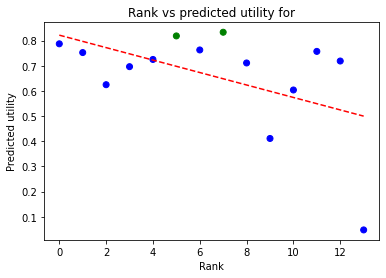

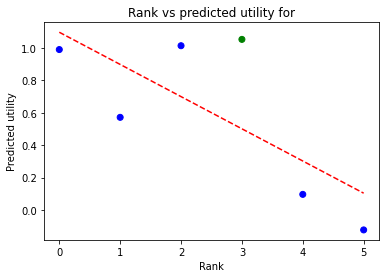

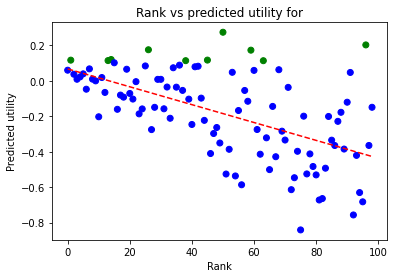

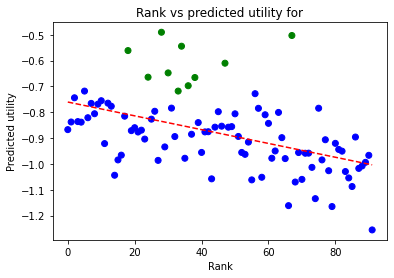

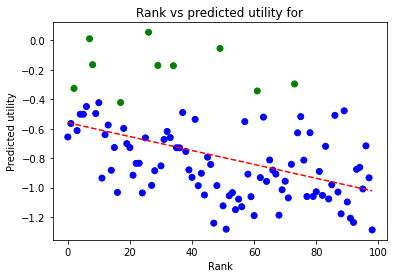

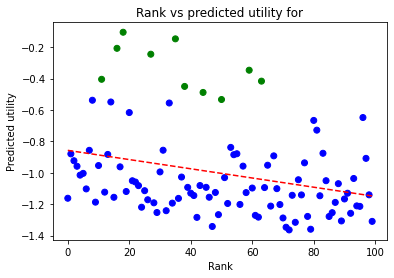

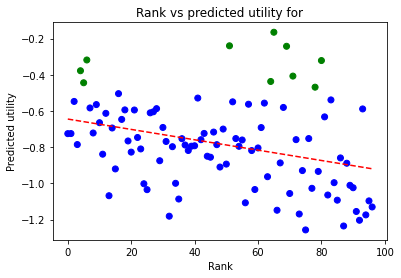

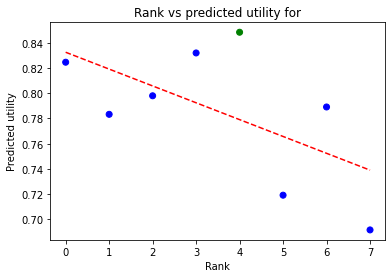

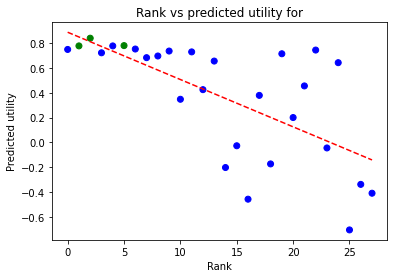

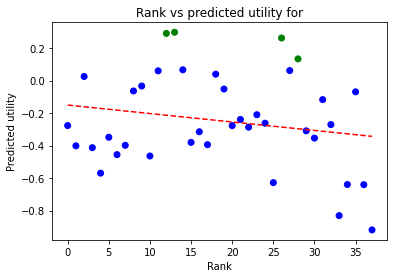

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import math
np.random.seed(2)
indices = np.random.choice(2500, 10)
for i in indices:

    val_row = val_df.iloc[i]
    predicted_row = predictions_df.iloc[i]
    


    predicted_means = np.array(predicted_row["predictions"])
    target_means = val_row["utilities"]

    sorted_indices = np.argsort(target_means)[::-1]

    predicted_means_sorted = predicted_means[sorted_indices]
    x = np.arange(0, len(predicted_means_sorted))

    sorted_indices_predicted = np.argsort(predicted_means_sorted)[::-1]

    colors = ["b"]  * len(predicted_means)

    top_10 = math.ceil(0.1 * len(sorted_indices_predicted)) 
    for j in range(top_10):
        c = sorted_indices_predicted[j]
        colors[c] = 'g'



    z = np.polyfit(x, predicted_means_sorted, 1)
    p = np.poly1d(z)
    plt.plot(x,p(x),"r--")






    plt.scatter(x, predicted_means_sorted, marker='o', c= colors,)
    plt.xlabel('Rank')
    plt.ylabel("Predicted utility")
    plt.title("Rank vs predicted utility for")


    plt.show()

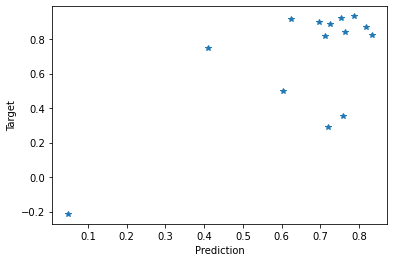

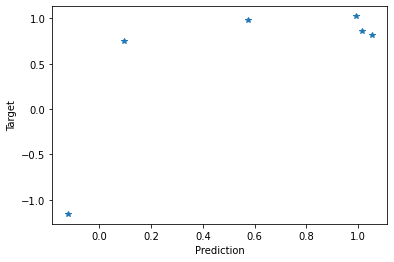

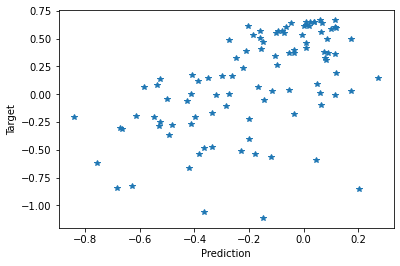

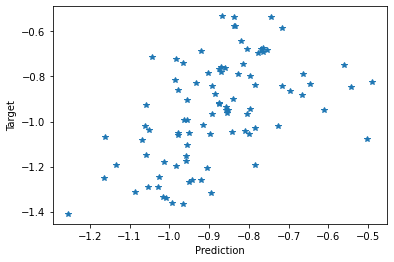

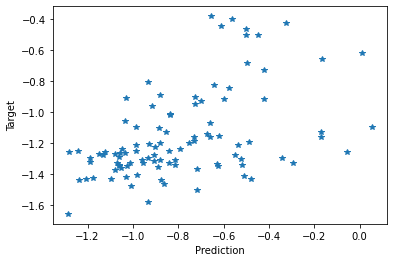

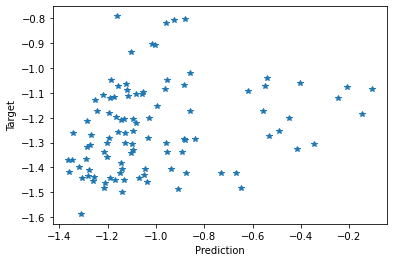

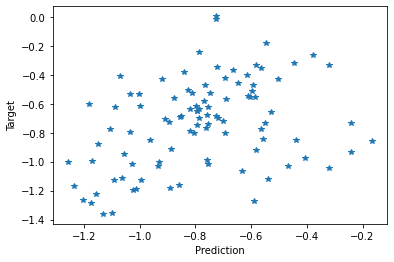

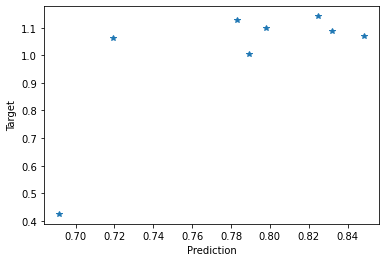

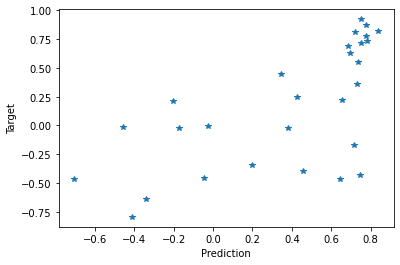

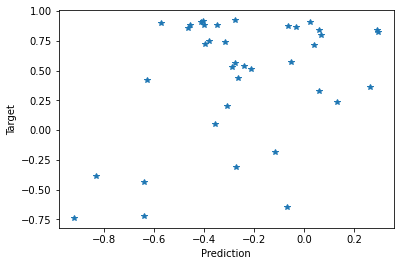

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import math
np.random.seed(2)
indices = np.random.choice(2500, 10)
for i in indices:

    val_row = val_df.iloc[i]
    predicted_row = predictions_df.iloc[i]
    


    predicted_means = np.array(predicted_row["predictions"])
    target_means = val_row["utilities"]
    
    plt.plot(predicted_means,target_means, '*')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.show()
    


In [9]:
# Rank correlation Uses: https://arxiv.org/pdf/2009.09025.pdf
from tqdm import tqdm

temp = predictions_df["predictions"].to_list()
all_predictions = []
for t in tqdm(temp):
    all_predictions += t.tolist()
print(all_predictions[:10])
all_predictions = np.array(all_predictions)
temp = val_df["utilities"].to_list()
all_true_values = []
for t in tqdm(temp):
    all_true_values += t.to_numpy().tolist()
all_true_values = np.array(all_true_values)
print(len(predictions_df["predictions"].to_list()))
print(len(val_df["utilities"].to_list()))
for i, (x, y) in enumerate(zip(predictions_df["predictions"].to_list(), val_df["utilities"].to_list())):
    assert len(x) == len(y), "{}: {} != {}".format(i, x, y)




100%|██████████████████████████████████████████████████████████████████████████| 2499/2499 [00:00<00:00, 833060.38it/s]


[0.3447842597961426, 0.4146411418914795, 0.7102289795875549, 0.6988805532455444, 0.07863879948854446, 0.49672114849090576, -1.2741682529449463, 0.4826093912124634, -0.026675790548324585, -0.13939861953258514]


100%|██████████████████████████████████████████████████████████████████████████| 2499/2499 [00:00<00:00, 999577.12it/s]

2499
2499


In [10]:

print(val_df.iloc[1491])

source                                Ich kann auch nicht schwimmen.
target                              I don't know how to swim either.
count              [65, 3, 1, 3, 8, 2, 6, 1, 1, 1, 1, 1, 1, 1, 1,...
hypotheses         [I can't swim either., I am not able to swim e...
utilities_count    [701, 72, 1, 1, 18, 11, 6, 18, 6, 1, 61, 4, 7,...
utilities          [1.0723711, 0.9062363, 0.8756748, 0.89354384, ...
Name: 1491, dtype: object


In [11]:
print(all_true_values.shape)
print(all_predictions.shape)

(97439,)
(97439,)


In [12]:
from scipy import stats

rho, pval = stats.spearmanr(all_predictions, all_true_values)
print(rho)
print(pval)

0.710211433254023
0.0


In [13]:
# NExt compute the MSE
MSE = np.mean((all_true_values - all_predictions)**2)
print("MSE: ", MSE)

MSE:  0.2696557272605755


In [14]:
# Next we check what happens if we use it as a decision rule:

# Pick the highest scoring one

def to_highest_scoring(x):
    max_index = np.argmax(x["predictions"])
    best = x["hypotheses"][max_index]
    
    return best

best_hypotheses = predictions_df.apply(to_highest_scoring, axis=1)
best_hypotheses

0                        I not speak German at all.
1                                  I love your age.
2                           I asked Tom to meet me.
3                        She really wants to leave.
4        The Germans like beer and looking for joy.
                           ...                     
2494             That bypassA A is a bar on rumors.
2495                      I am at home where I can.
2496                            I love his sweater.
2497    Do you know what's most angry with me, Tom?
2498              For whom party are you listening?
Length: 2499, dtype: object

In [21]:
# Get the top 10
from math import ceil
def top_10(x):
    '''
    Keeps the top 10 best percent
    '''
    
    if len(x["hypotheses"]) <= 1:
        return x["hypotheses"]
    sorted_indices = np.argsort(x["predictions"])

    top = ceil(0.25 * len(x["predictions"]))
    top_n = np.array(x["ground_truth"])[sorted_indices][:top]
    
    
    best = np.max(top_n)

    best_index = np.where(x["ground_truth"] == best)[0]
    best = x["hypotheses"][best_index]
    return best
predictions_df["ground_truth"] = val_df["utilities"]

top_filtered = predictions_df.apply(top_10, axis=1)
top_filtered

0                     [I simply don't speak German.]
1                            [I once were your age.]
2                           [I asked Tom to see me.]
3                             [She does want to go.]
4            [The Germans love beer and vegetables.]
                            ...                     
2494    [The▁HochzeitA runs a bar at tired Russian.]
2495                    [My heart is, I am at home.]
2496                            [I like his jumper.]
2497      [Do you know what annoy me the most, Tom?]
2498                 [Which party do you belong to?]
Length: 2499, dtype: object

In [16]:
### Lastly we calc the 
val_df["utilities"].iloc[1492]

<PandasArray>
[   1.0151777,    0.8415896,    0.6189353,   0.97511643,    0.9737194,
  -0.91622084,     0.978855,   0.44103885,   -0.9142382,    1.0209352,
   0.81683946,   0.98770154,   0.64196044, -0.024713593,   0.96367973,
   0.29963765,    0.5058572,    0.8096563,   -1.2517684,   -0.7086341,
   0.98762906,   -0.4430108,    0.9449954,   0.99445355,   0.85192746,
   0.18550794,  -0.38448974,  -0.30749437,    0.7329068,     1.022996,
  -0.29854095,    0.8111564]
Length: 32, dtype: float32